# Simple End-to-End Example

Ici on présente un exemple simple et complet avec une collection de traces simulées à partir d'un réseau.

In [2]:
import os
import sys

import matplotlib.pyplot as plt

# Import de tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import de OFNP
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import tracklib as tkl

  0% (0 of 80) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--

PAGE 1/1


100% (80 of 80) |########################| Elapsed Time: 0:00:00 Time:  0:00:000000
 16% (13 of 80) |###                     | Elapsed Time: 0:00:00 ETA:   0:00:00

Building [4411 x 4202] spatial index...


100% (80 of 80) |########################| Elapsed Time: 0:00:00 Time:  0:00:000:00


Number of edges= 80
Number of nodes= 70


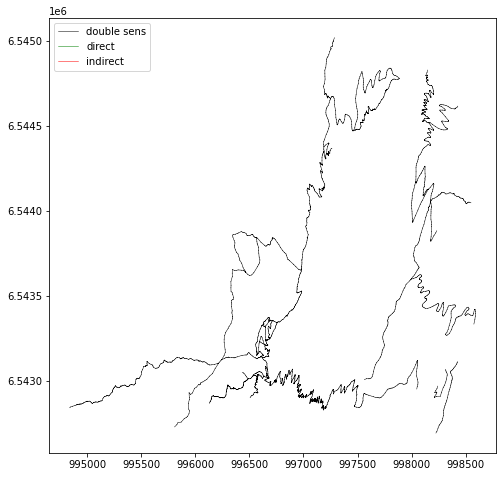

In [3]:
xmin = 6.8165550
xmax = 6.8496992
ymin = 45.92171
ymax = 45.93695

bbox = tkl.Bbox(tkl.GeoCoords(xmin, ymin), tkl.GeoCoords(xmax, ymax))
tolerance = 0.0001

spatialIndex = True

network = tkl.NetworkReader.requestFromIgnGeoportail(bbox, tolerance=tolerance, spatialIndex=spatialIndex)
network.toENUCoords(2154)

plt.figure(figsize=(8, 8))
network.plot('k-', '', 'g-', 'r-', 0.5, plt)
print ('Number of edges=', len(network.EDGES))
print ('Number of nodes=', len(network.NODES))
plt.legend()

In [4]:
noiser = tkl.NoiseProcess(amps=5, kernels=tkl.ExponentialKernel(500))
simu = tkl.generateTracksOnNetwork(network, N=1000, p_round_trip=0.05, p_cplx_trip=0.10, resolution=1, noiser=noiser)

100% (1000 of 1000) |####################| Elapsed Time: 0:01:16 Time:  0:01:160106


------------------------------------------------------------
583 (58.3 %) tracks generated on network
------------------------------------------------------------


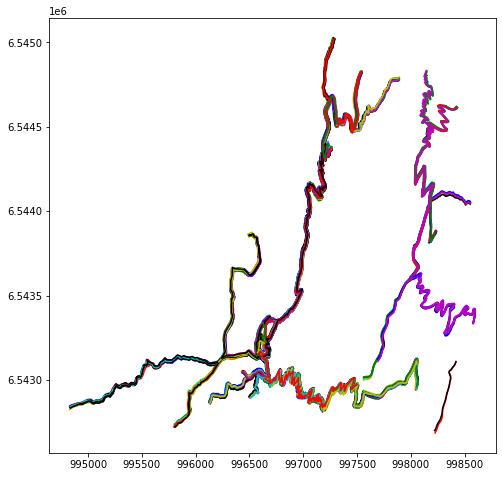

In [8]:
plt.figure(figsize=(8, 8))
simu.plot(append=plt)